In [1]:
import pandas as pd

events = pd.read_csv("event_logs.csv")
marketing = pd.read_csv("marketing_summary.csv")
trends = pd.read_csv("trend_report.csv")

print(events.head())
print(marketing.head())
print(trends.head())

print(events.info())
print(marketing.info())
print(trends.info())

  user_id      event_type        event_time product_id   amount col_6  col_7  \
0   U0099        checkout  2023-06-03 04:13       P010      NaN     C  13.05   
1   U0240    wishlist_add  2023-06-03 05:08       P020  2900.63   NaN    NaN   
2   U0374  profile_update  2023-06-05 06:22       P028      NaN     A    NaN   
3   U0122       page_view  2023-06-06 03:45       P001      NaN     C    NaN   
4   U0211    wishlist_add  2023-06-03 12:38       P015  1728.27     A  40.19   

   col_8 col_9  col_10  ...  col_41 col_42  col_43  col_44 col_45  col_46  \
0    NaN     B    0.81  ...     NaN      B   39.66   138.0      C     NaN   
1    NaN     C     NaN  ...   714.0    NaN   39.97   507.0      B     NaN   
2    NaN     B   60.06  ...     NaN    NaN     NaN   293.0    NaN     NaN   
3  747.0     B     NaN  ...   365.0      C   67.84   705.0      A   96.06   
4  515.0     A     NaN  ...     NaN      C     NaN   876.0    NaN     NaN   

   col_47 col_48  col_49  col_50  
0   902.0      A     

In [3]:
events.isnull().sum()
events.duplicated().sum()
events.columns

Index(['user_id', 'event_type', 'event_time', 'product_id', 'amount', 'col_6',
       'col_7', 'col_8', 'col_9', 'col_10', 'col_11', 'col_12', 'col_13',
       'col_14', 'col_15', 'col_16', 'col_17', 'col_18', 'col_19', 'col_20',
       'col_21', 'col_22', 'col_23', 'col_24', 'col_25', 'col_26', 'col_27',
       'col_28', 'col_29', 'col_30', 'col_31', 'col_32', 'col_33', 'col_34',
       'col_35', 'col_36', 'col_37', 'col_38', 'col_39', 'col_40', 'col_41',
       'col_42', 'col_43', 'col_44', 'col_45', 'col_46', 'col_47', 'col_48',
       'col_49', 'col_50'],
      dtype='object')

In [5]:
marketing.isnull().sum()
marketing.duplicated().sum()
marketing.columns

Index(['date', 'users_active', 'total_sales', 'new_customers',
       'report_generated', 'col_6', 'col_7', 'col_8', 'col_9', 'col_10',
       'col_11', 'col_12', 'col_13', 'col_14', 'col_15', 'col_16', 'col_17',
       'col_18', 'col_19', 'col_20', 'col_21', 'col_22', 'col_23', 'col_24',
       'col_25', 'col_26', 'col_27', 'col_28', 'col_29', 'col_30', 'col_31',
       'col_32', 'col_33', 'col_34', 'col_35', 'col_36', 'col_37', 'col_38',
       'col_39', 'col_40', 'col_41', 'col_42', 'col_43', 'col_44', 'col_45',
       'col_46', 'col_47', 'col_48', 'col_49', 'col_50'],
      dtype='object')

In [7]:
trends.isnull().sum()
trends.duplicated().sum()
trends.columns

Index(['week', 'avg_users', 'sales_growth_rate', 'col_4', 'col_5', 'col_6',
       'col_7', 'col_8', 'col_9', 'col_10', 'col_11', 'col_12', 'col_13',
       'col_14', 'col_15', 'col_16', 'col_17', 'col_18', 'col_19', 'col_20',
       'col_21', 'col_22', 'col_23', 'col_24', 'col_25', 'col_26', 'col_27',
       'col_28', 'col_29', 'col_30', 'col_31', 'col_32', 'col_33', 'col_34',
       'col_35', 'col_36', 'col_37', 'col_38', 'col_39', 'col_40', 'col_41',
       'col_42', 'col_43', 'col_44', 'col_45', 'col_46', 'col_47', 'col_48',
       'col_49', 'col_50'],
      dtype='object')

In [9]:
events = events[
    [
        "user_id",
        "event_type",
        "event_time",
        "product_id",
        "amount"
    ]
]

events = events.drop_duplicates()
events["amount"] = events["amount"].fillna(0)
events = events.dropna(subset=["user_id"])

In [11]:
marketing = marketing.drop_duplicates()

marketing["users_active"] = (
    marketing["users_active"]
    .fillna(0)
)

marketing["total_sales"] = (
    marketing["total_sales"]
    .fillna(0)
)

marketing["new_customers"] = (
    marketing["new_customers"]
    .fillna(0)
)

In [13]:
trends = trends.drop_duplicates()

trends["avg_users"] = (
    trends["avg_users"]
    .fillna(0)
)

trends["sales_growth_rate"] = (
    trends["sales_growth_rate"]
    .fillna(0)
)

In [15]:
events["event_time"] = pd.to_datetime(
    events["event_time"]
)

events["event_date"] = (
    events["event_time"].dt.date
)

In [17]:
marketing["date"] = pd.to_datetime(
    marketing["date"]
)

In [21]:
trends["week"] = trends["week"].astype(str)

In [25]:
events.to_csv(
    "cleaned_event_logs.csv",
    index=False
)

marketing.to_csv(
    "cleaned_marketing_summary.csv",
    index=False
)

trends.to_csv(
    "cleaned_trend_report.csv",
    index=False
)

In [27]:
events["user_id"].nunique()
events["event_type"].value_counts()
events["amount"].sum()

1573401.37

In [29]:
marketing["total_sales"].sum()
marketing["users_active"].mean()
marketing["new_customers"].sum()

765

In [31]:
average_users = trends["avg_users"].mean()

average_growth = trends["sales_growth_rate"].mean()

print("Average Weekly Users:", average_users)
print("Average Sales Growth Rate:", average_growth)

Average Weekly Users: 257.95
Average Sales Growth Rate: 0.04664999999999999


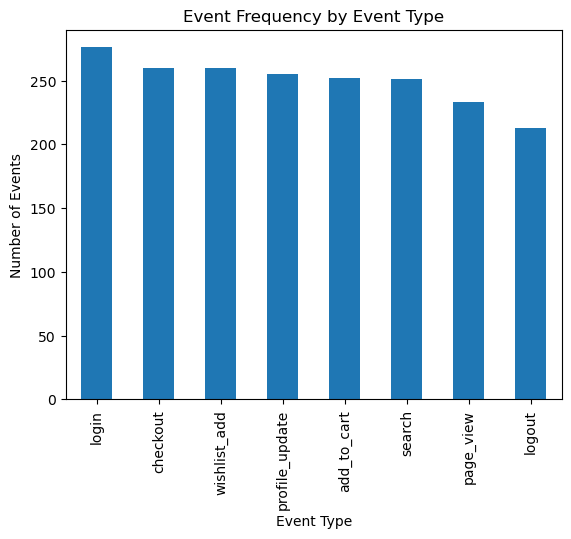

In [33]:
import matplotlib.pyplot as plt

event_counts = events["event_type"].value_counts()

event_counts.plot(
    kind="bar"
)

plt.title("Event Frequency by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.show()

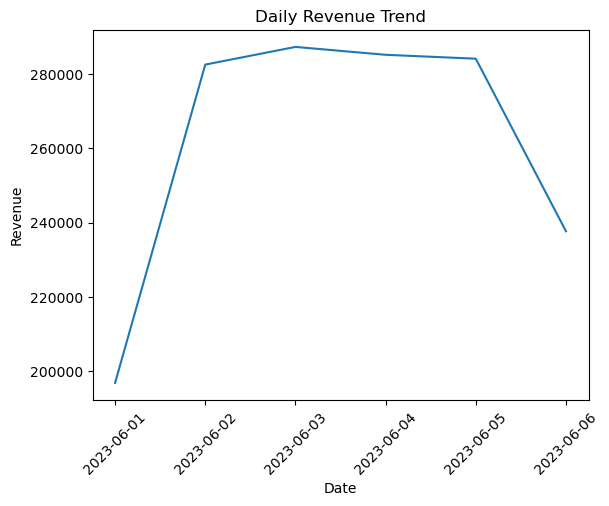

In [35]:
daily_revenue = (
    events.groupby("event_date")["amount"]
    .sum()
)

daily_revenue.plot(
    kind="line"
)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

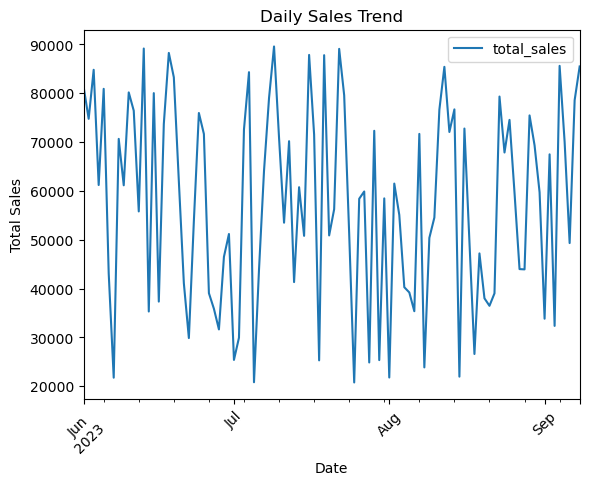

In [37]:
marketing.plot(
    x="date",
    y="total_sales",
    kind="line"
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

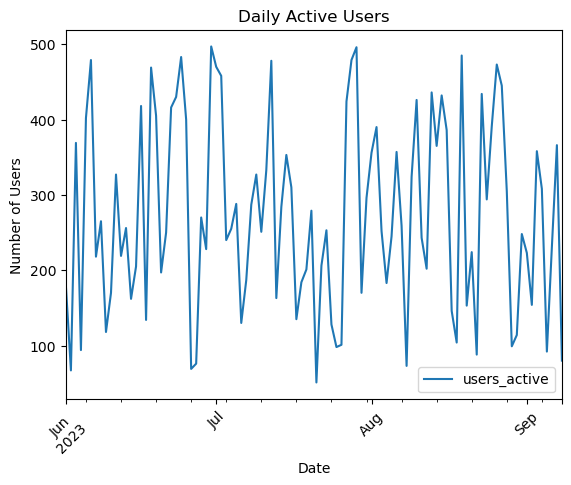

In [39]:
marketing.plot(
    x="date",
    y="users_active",
    kind="line"
)

plt.title("Daily Active Users")
plt.xlabel("Date")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

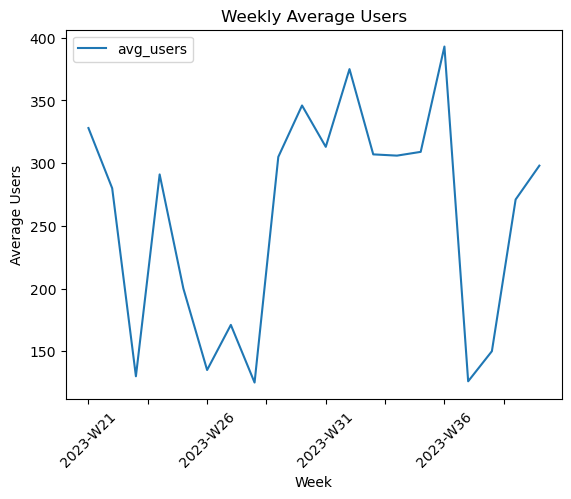

In [41]:
trends.plot(
    x="week",
    y="avg_users",
    kind="line"
)

plt.title("Weekly Average Users")
plt.xlabel("Week")
plt.ylabel("Average Users")
plt.xticks(rotation=45)
plt.show()

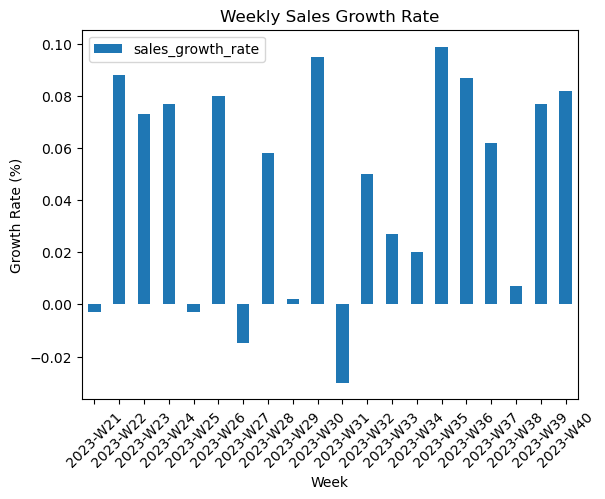

In [43]:
trends.plot(
    x="week",
    y="sales_growth_rate",
    kind="bar"
)

plt.title("Weekly Sales Growth Rate")
plt.xlabel("Week")
plt.ylabel("Growth Rate (%)")
plt.xticks(rotation=45)
plt.show()